In [15]:
import pandas as pd
import missingno
import sys

sys.path.insert(0, "../Modules")

from preprocessing_utils import *

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [16]:
NUTS0 = 'GR'
NUTS2 = 'Attica'

In [17]:
dataset = pd.read_csv(f'data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv', encoding=enc)
geomorphological = pd.read_csv(f'data/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [18]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2010-01-01,αττικης,αγιας βαρβαρας,26,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,2.4,26759.0,10925.9,44.75555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.71,NaN,14.482,8.504000,14.580000,8.572000,20.191667,11.492353,26.351538,13.455263,12.5,15.7,0.0,1,0,0
1,23.82642,38.00806,2010-01-01,αττικης,αγιας παρασκευης,49,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,7.9,62157.0,7557.5,44.85879,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14.83,17.75,11.91,12.890,7.754000,15.184545,7.190000,19.492667,10.508889,24.152667,12.792500,11.8,15.9,0.0,1,0,0
2,23.73031,37.93357,2010-01-01,αττικης,αγιου δημητριου,23,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,5.0,71747.0,14402.8,44.74465,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,16.56,19.29,13.83,14.805,6.707143,13.976000,9.936000,21.635714,12.007500,24.690000,14.180476,15.0,18.5,0.0,1,0,0
3,23.71341,38.04721,2010-01-01,αττικης,αγιων αναργυρων καματερου,43,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.2,61427.0,6833.8,44.83209,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,15.54,18.85,12.23,12.010,7.359091,15.152000,7.963333,21.904000,10.726667,26.154000,12.920000,10.8,16.1,0.0,1,0,0
4,23.34009,37.69503,2010-01-01,αττικης,αγκιστριου,5,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,13.4,1107.0,85.2,44.33593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.30,20.49,16.11,13.615,10.541111,12.760000,9.517273,16.742000,11.208667,18.293333,13.694211,9.0,16.1,0.0,1,0,0


In [19]:
geomorphological.head()

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,23.46396,37.33108,1426.812825,9526.118856,24,50.314461,387.046710,184.247277,0.0,1.000000
1,23.47454,37.73169,1901.598942,5182.958716,12,258.873851,229.509683,196.039884,0.0,1.812562
2,23.49722,37.71372,2205.171204,3731.540147,25,207.589234,289.724049,176.975937,0.0,1.891786
3,23.51990,37.74966,1606.369095,2361.867631,31,254.408817,128.656796,180.511498,0.0,1.306699
4,23.72137,37.99391,6716.989270,1493.626330,2,212.539863,68.539566,184.962678,0.0,1.629068


In [20]:
distances, indicies = calculate_nearest_topological(dataset, geomorphological)

In [21]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 3.9952337143388092


In [22]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

In [23]:
for index in indicies:
    df_geo = df_geo.append(geomorphological.iloc[[index]])

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [24]:
dataset = pd.concat([dataset, df_geo], axis=1, join = 'outer')

In [25]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,23.65697,37.99220,2010-01-01,αττικης,αγιας βαρβαρας,26,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,2.4,26759.0,10925.9,44.75555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.71,NaN,14.482,8.504000,14.580000,8.572000,20.191667,11.492353,26.351538,13.455263,12.5,15.7,0.0,1,0,0,4986.234414,2455.349701,5,136.450508,101.355755,167.697476,0.000000,1.730851
1,23.82642,38.00806,2010-01-01,αττικης,αγιας παρασκευης,49,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,7.9,62157.0,7557.5,44.85879,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14.83,17.75,11.91,12.890,7.754000,15.184545,7.190000,19.492667,10.508889,24.152667,12.792500,11.8,15.9,0.0,1,0,0,14419.406690,1186.404835,17,195.624294,247.122730,186.152654,0.000000,4.727984
2,23.73031,37.93357,2010-01-01,αττικης,αγιου δημητριου,23,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,5.0,71747.0,14402.8,44.74465,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,16.56,19.29,13.83,14.805,6.707143,13.976000,9.936000,21.635714,12.007500,24.690000,14.180476,15.0,18.5,0.0,1,0,0,3030.589205,923.760750,6,197.484591,76.843700,185.824323,0.000000,10.672627
3,23.71341,38.04721,2010-01-01,αττικης,αγιων αναργυρων καματερου,43,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.2,61427.0,6833.8,44.83209,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,15.54,18.85,12.23,12.010,7.359091,15.152000,7.963333,21.904000,10.726667,26.154000,12.920000,10.8,16.1,0.0,1,0,0,10104.114693,102.938851,2,185.470524,110.515124,178.698121,0.000000,247.581759
4,23.34009,37.69503,2010-01-01,αττικης,αγκιστριου,5,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,13.4,1107.0,85.2,44.33593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.30,20.49,16.11,13.615,10.541111,12.760000,9.517273,16.742000,11.208667,18.293333,13.694211,9.0,16.1,0.0,1,0,0,703.682089,16702.208116,8,264.649030,132.349467,189.350397,0.115955,1.705489


<AxesSubplot:>

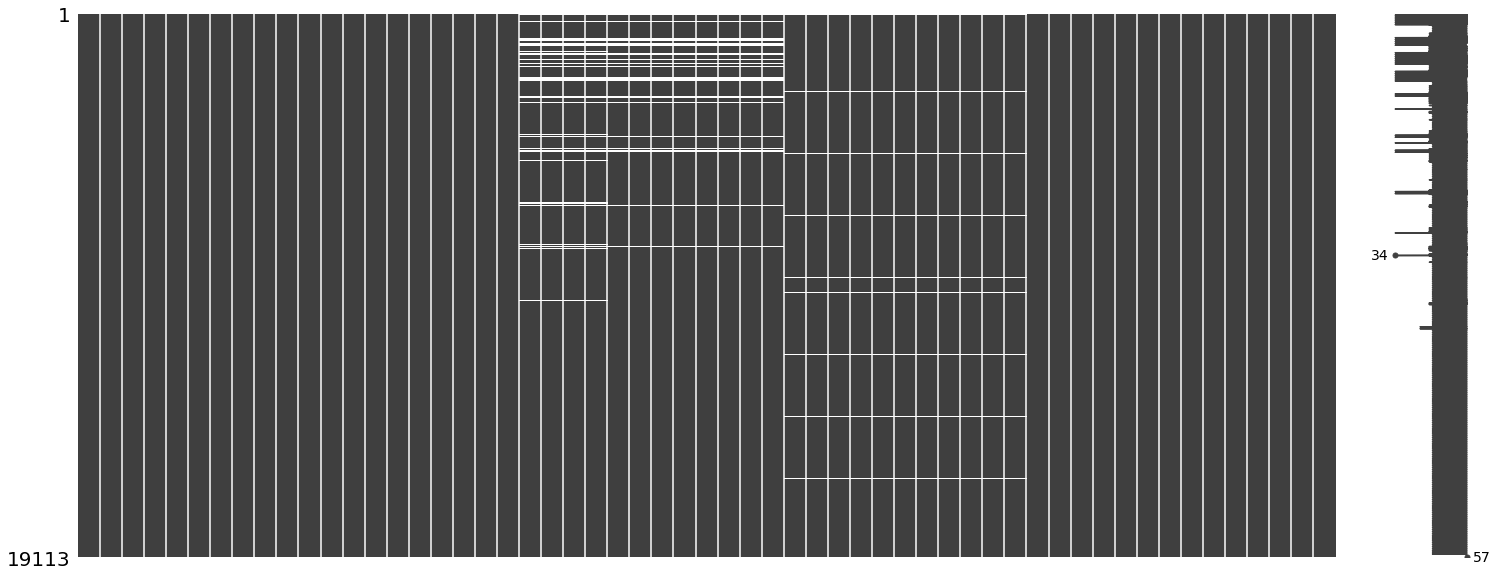

In [26]:
missingno.matrix(dataset)

In [27]:
cols = dataset.columns

In [28]:
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'lau1_id', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'mosq_pred', 'mosq_previous', 'case',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m'],
      dtype='object')

In [29]:
len(cols)

57

In [30]:
rearranged = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'lau1_id', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case']

In [31]:
len(rearranged)

57

In [32]:
dataset = dataset[rearranged]

In [33]:
dataset.to_csv(f"data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv", encoding = enc, index = False)